In [25]:
from koala.voronization import generate_lattice
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl


from copy import copy 
import numpy as np
import matplotlib.pyplot as plt

In [26]:
points = uniform(40)
lattice = generate_lattice(points)

dimer = gu.dimerise(lattice)
coloring = color_lattice(lattice)

dimer_list = np.where(dimer == 1)[0]


In [27]:


def _dimer_check(edge_indices,dimer_list, raise_error = True):


    # check dimerisation is provided as a list of dimers
    if len(np.unique(dimer_list)) == 2:
     if np.all(np.unique(dimer_list) == np.array([0,1])):
        raise ValueError('must provide list of dimers not dimer colouring')
    
    # make sure no dimers touch each other
    dimer_vertices = edge_indices[dimer_list]
    unique_verts, count = np.unique(dimer_vertices, return_counts = True)
    if not np.all(count == 1):

        # if we are not raising an error, we can return the offending dimers
        if not raise_error:
            offending_dimers = np.where(count > 1)[0]
            return offending_dimers
        
        # otherwise we raise an error
        raise ValueError('not a valid dimerisation -- no dimers can touch each other')


def _collapse_edges(lattice, dimer_list, return_lattice = False):
    
    _dimer_check(lattice.edges.indices,dimer_list)

    lattice = copy(lattice)

    new_vertices = lattice.vertices.positions
    new_crossing = lattice.edges.crossing

    for n in dimer_list:
        edge = lattice.edges.indices[n]
        p1 = lattice.vertices.positions[edge[0]]
        v = lattice.edges.vectors[n]
        pos = p1 + v/2 #position of the new collapsed vertex
        
        sector_1 = (p1//1).astype(int)
        sector_2 = ((p1 + v)//1).astype(int)
        sector_mean = ((pos)//1).astype(int)


        # if the collapsed edge crosses a boundary we need to change the crossing of the adjacent edges
        edge_crossing = lattice.edges.crossing[n]
        if np.any(edge_crossing != 0):

            # now we check whether the first or second vertex has been shifted over the boundary
            # if np.any(pos//1 != 0):
            if np.any(sector_1 != sector_mean):
                # p1 in a different sector
                p1_neighbours = lattice.vertices.adjacent_edges[edge[0]]
                adjacent_indices = lattice.edges.indices[p1_neighbours]
                signs = 1-2*np.where(adjacent_indices == edge[0])[1]
                new_crossing[p1_neighbours] += signs[:,None]*(sector_1 - sector_mean)

            if np.any(sector_2 != sector_mean):
                # p2 in a different sector
                p2_neighbours = lattice.vertices.adjacent_edges[edge[1]]
                adjacent_indices = lattice.edges.indices[p2_neighbours]
                signs = 1-2*np.where(adjacent_indices == edge[1])[1]                
                new_crossing[p2_neighbours]+= signs[:,None]*(sector_2 - sector_mean)

            pos = pos%1

        new_vertices[edge[0]] = pos
        new_vertices[edge[1]] = pos
    
    if return_lattice:
        return Lattice(new_vertices, lattice.edges.indices  , new_crossing)
    else:
        return [new_vertices, lattice.edges.indices, new_crossing]
    
def _rewire_and_remove(collapsed_system, dimer_list, return_lattice = False):

    # now we remove the doubled vertices and rewire their edges 
    _dimer_check(collapsed_system[1],dimer_list)
    
    print('dimer list', dimer_list)
    new_vertices, new_indices, new_crossing = collapsed_system

    # for each dimer, we remove the second
    v_keep, v_kill = new_indices[dimer_list].T
    for vertex_keep, vertex_kill in zip(v_keep, v_kill):
        new_indices[new_indices == vertex_kill] = vertex_keep

    # find and remove the self loops
    self_loops = new_indices[:,0] - new_indices[:,1] == 0
    new_indices = new_indices[~self_loops]
    new_crossing = new_crossing[~self_loops]

    # remove the vertices that now have no connections
    removal_bool = np.full(len(new_vertices[:,0]), False)
    removal_bool[v_kill] = True

    # we have to relabel the edge index values after the vertices are removed
    subtraction = np.cumsum(removal_bool)
    vertex_relabel = np.arange(len(new_vertices[:,0])) - subtraction
    vertex_relabel[v_kill] = -1
    new_indices = vertex_relabel[new_indices]
    if -1 in new_indices:
        raise ValueError('There are edges still connected to the vertices that we tried to remove')
    
    new_vertices = new_vertices[~removal_bool]

    if return_lattice:
        return Lattice(new_vertices, new_indices, new_crossing)
    else:
        return [new_vertices, new_indices, new_crossing]

def _find_duplicate_edges(collapsed_system):
    _, new_indices, _ = collapsed_system
    
    # find duplicate edges
    _, index, count = np.unique(np.sort(new_indices,1), axis = 0, return_counts = True, return_index = True)
    new_dimer = index[count > 1]

    if len(new_dimer) == 0:
        return None
    
    return new_dimer

def collapse_doubled_edges(collapsed_system, dimer_list):
    pass


def dimer_collapse(lattice, dimer_list):

    # first we collapse the edges
    collapsed_system = _collapse_edges(lattice, dimer_list)
    print('new dimers', dimer_list)

    # now we remove the doubled vertices and rewire their edges
    rewired_system = _rewire_and_remove(collapsed_system, dimer_list)

    # find duplicate edges
    doubled_edges = _find_duplicate_edges(rewired_system)
    

        
    return Lattice(*rewired_system)




new dimers [  1   3   5   8  10  11  12  13  14  17  18  22  25  28  33  36  37  41
  43  44  49  52  54  61  64  65  70  71  73  75  76  81  83  85  88  90
  96  98 100 107]
dimer list [  1   3   5   8  10  11  12  13  14  17  18  22  25  28  33  36  37  41
  43  44  49  52  54  61  64  65  70  71  73  75  76  81  83  85  88  90
  96  98 100 107]


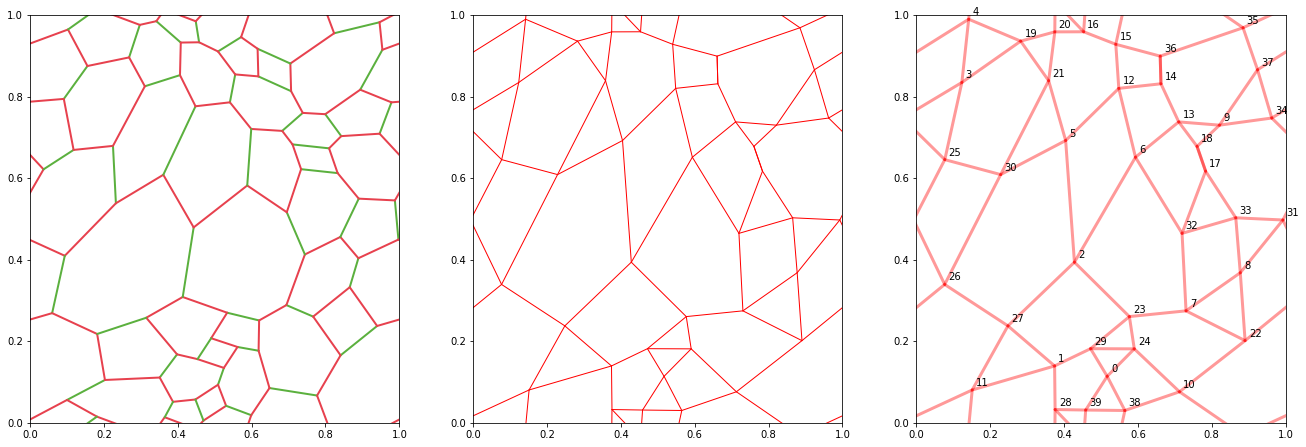

In [28]:


l2 = _collapse_edges(lattice, dimer_list, True)    
l2_bundle = _collapse_edges(lattice, dimer_list)   

l_out = dimer_collapse(lattice, dimer_list)


scale = 1.5
fig, ax = plt.subplots(1,3,figsize = (15*scale,5*scale))
ax = ax.flatten()
pl.plot_edges(lattice, dimer,ax = ax[0],linewidth = 2)
pl.plot_edges(l2, dimer,ax = ax[1], color = 'r', alpha = 1, linewidth = 1)
# pl.plot_vertex_indices(l2, ax = ax[1])

pl.plot_edges(l_out,ax = ax[2], color = 'r', alpha = 0.4, linewidth = 3)
pl.plot_vertex_indices(l_out, ax = ax[2])
# pl.plot_edge_indices(l_out, ax = ax[2])





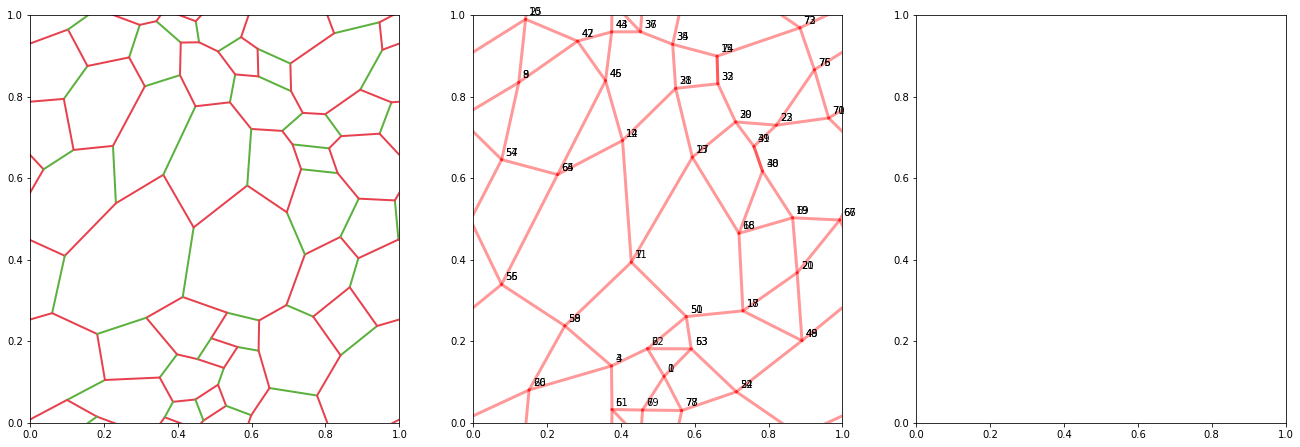

In [29]:
scale = 1.5
fig, ax = plt.subplots(1,3,figsize = (15*scale,5*scale))
ax = ax.flatten()
pl.plot_edges(lattice, dimer,ax = ax[0],linewidth = 2)
pl.plot_edges(l2, dimer,ax = ax[1], color = 'r', alpha = 0.4, linewidth = 3)
pl.plot_vertex_indices(l2, ax = ax[1])

# pl.plot_edges(l_out,ax = ax[2], color = 'r', alpha = 0.4, linewidth = 3)
# pl.plot_vertex_indices(l_out, ax = ax[2])
# # pl.plot_edge_indices(l_out, ax = ax[2])

dimer list [  1   3   5   8  10  11  12  13  14  17  18  22  25  28  33  36  37  41
  43  44  49  52  54  61  64  65  70  71  73  75  76  81  83  85  88  90
  96  98 100 107]
new dimers [48 54]
dimer list [48 54]


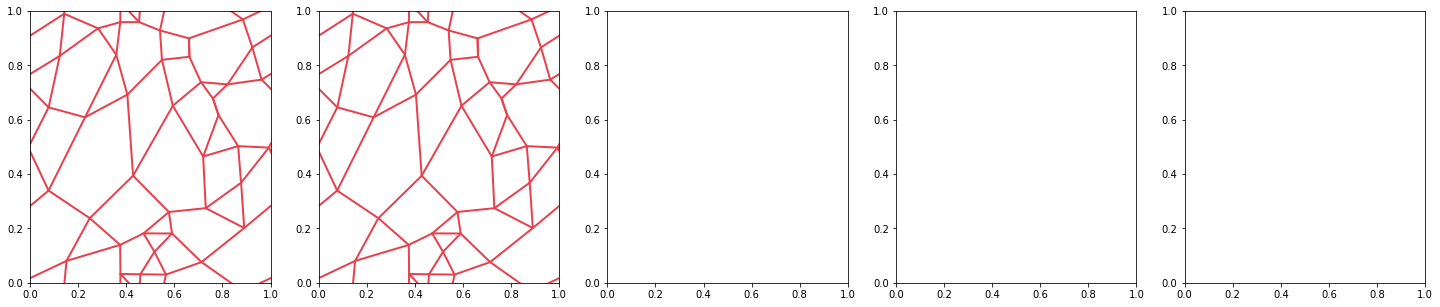

In [30]:
def dimer_collapse_verbose(lattice, dimer_list):

    fig, ax = plt.subplots(1,5,figsize = (25,5))

    # first we collapse the edges
    collapsed_system = _collapse_edges(lattice, dimer_list)

    dimer = np.zeros(len(collapsed_system[1]))
    dimer[dimer_list] = 1
    pl.plot_edges(Lattice(*collapsed_system),dimer, ax = ax[0], linewidth = 2)

    # now we remove the doubled vertices and rewire their edges
    rewired_system = _rewire_and_remove(collapsed_system, dimer_list)
    pl.plot_edges(Lattice(*rewired_system), ax = ax[1], linewidth = 2)

    # find duplicate edges
    new_dimers = _find_duplicate_edges(rewired_system)

    n = 0
    while new_dimers is not None and n < 10:
        print('new dimers', new_dimers)
        collapsed_system = _collapse_edges(Lattice(*rewired_system), new_dimers)
        rewired_system = _rewire_and_remove(collapsed_system, new_dimers)
        new_dimers = _find_duplicate_edges(rewired_system)
        n += 1
        
    return Lattice(*rewired_system)

l_out = dimer_collapse_verbose(lattice, dimer_list)